In [1]:
#%%
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
domain='d03'
#%load domain geometry  
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
gridded_data_path = basepath+'historical/variables_complete/'



This notebook will compute the monthly averages, plot the seasonal cylces,make bar pots of the seasona changes and compuet the standard error. 
Note that the fact we are on a 300x300 grid means we have to be a bit careful about alignment between the masks and the data. 

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


# ============================================================
# Helper: build aligned area weights
# ============================================================

def build_weights(data):

    sample = data.isel(time=0)

    lat = sample["lat"]
    print('sample lat', lat)


        
    weights = xr.DataArray(
        np.cos(np.deg2rad(lat)),
        dims=lat.dims,
        coords=lat.coords
    )
    print('weight dims', weights.dims)
    return weights


# ============================================================
# Helper: weighted regional mean time series
# ============================================================

def weighted_mean_timeseries(data, weights, mask):

    masked_weights = weights.where(mask, 0)

    return (
        data
        .weighted(masked_weights)
        .mean(("lon", "lat"))
    )

# ============================================================
# Monthly climatology + delta + SEM
# ============================================================

def climatology_delta_sem(hist_ts, fut_ts, relative=False):

    hist_clim = hist_ts.groupby("time.month").mean()
    fut_clim = fut_ts.groupby("time.month").mean()

    if relative:
        delta = 100 * (fut_clim - hist_clim) / hist_clim
    else:
        delta = fut_clim - hist_clim

    hist_sem = (
        hist_ts
        .groupby("time.month")
        .std("time", ddof=1)
        /
        np.sqrt(
            hist_ts.groupby("time.month").count()
        )
    )

    fut_sem = (
        fut_ts
        .groupby("time.month")
        .std("time", ddof=1)
        /
        np.sqrt(
            fut_ts.groupby("time.month").count()
        )
    )

    sem = np.sqrt(hist_sem**2 + fut_sem**2)

    if relative:
        sem = 100 * sem / np.abs(hist_clim)

    return (
        hist_clim.values,
        fut_clim.values,
        delta.values,
        sem.values
    )


# ============================================================
# Main driver
# ============================================================

def get_monthly_climatologies(variable, domain):

    if variable == "t":
        var = "T2"
        filename = f"t_{domain}_daily_newdim"
        relative = False

    elif variable == "pr":
        var = "pr"
        filename = f"pr_{domain}_daily"
        relative = True

    elif variable == "wind":

        var = "wspd"
        relative = True

        if domain == "d03":
            filename = "wind_d03_daily_wspd"
        else:
            filename = f"wind_{domain}_daily"

    else:
        raise ValueError(variable)

    base = "/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/"

    hist = xr.open_dataset(
        f"{base}/historical/variables_complete/{filename}.nc"
    )[var]

    rcp45 = xr.open_dataset(
        f"{base}/rcp45/variables_complete/{filename}.nc"
    )[var]

    rcp85 = xr.open_dataset(
        f"{base}/rcp85/variables_complete/{filename}.nc"
    )[var]

    if variable == "t":

        rename = {
            "longitude": "lon",
            "latitude": "lat"
        }

        hist = hist.rename(rename)
        rcp45 = rcp45.rename(rename)
        rcp85 = rcp85.rename(rename)

    hist = hist.resample(time="1MS").mean()
    rcp45 = rcp45.resample(time="1MS").mean()
    rcp85 = rcp85.resample(time="1MS").mean()

# === Load land mask ===
    landmask_ds = xr.open_dataset(geo_em_file)
    
    landmask = (
        landmask_ds["LANDMASK"]
        .squeeze()
        .rename({
            "south_north": "lat",
            "west_east": "lon"
        })
    )
    
    # attach true coordinates
    landmask = landmask.assign_coords(
        lat=(
            ("lat", "lon"),
            landmask_ds["XLAT_M"].squeeze().values
        ),
        lon=(
            ("lat", "lon"),
            landmask_ds["XLONG_M"].squeeze().values
        )
    )
    
    land_mask = (landmask.values == 1)
    ocean_mask = ~land_mask

    weights = build_weights(hist)


    hist_land_ts = weighted_mean_timeseries(
        hist,
        weights,
        land_mask
    )

    hist_ocean_ts = weighted_mean_timeseries(
        hist,
        weights,
        ocean_mask
    )

    rcp45_land_ts = weighted_mean_timeseries(
        rcp45,
        weights,
        land_mask
    )

    rcp45_ocean_ts = weighted_mean_timeseries(
        rcp45,
        weights,
        ocean_mask
    )

    rcp85_land_ts = weighted_mean_timeseries(
        rcp85,
        weights,
        land_mask
    )

    rcp85_ocean_ts = weighted_mean_timeseries(
        rcp85,
        weights,
        ocean_mask
    )

    (
        hist_land,
        r45_land,
        delta45_land,
        sem45_land
    ) = climatology_delta_sem(
        hist_land_ts,
        rcp45_land_ts,
        relative
    )

    (
        hist_ocean,
        r45_ocean,
        delta45_ocean,
        sem45_ocean
    ) = climatology_delta_sem(
        hist_ocean_ts,
        rcp45_ocean_ts,
        relative
    )

    (
        _,
        r85_land,
        delta85_land,
        sem85_land
    ) = climatology_delta_sem(
        hist_land_ts,
        rcp85_land_ts,
        relative
    )

    (
        _,
        r85_ocean,
        delta85_ocean,
        sem85_ocean
    ) = climatology_delta_sem(
        hist_ocean_ts,
        rcp85_ocean_ts,
        relative
    )

    delta_field = (
        rcp45.groupby("time.month").mean()
        -
        hist.groupby("time.month").mean()
    )

    delta_land_direct = (
        delta_field
        .weighted(weights.where(land_mask, 0))
        .mean(("lat", "lon"))
    )
    
    delta_ocean_direct = (
        delta_field
        .weighted(weights.where(ocean_mask, 0))
        .mean(("lat", "lon"))
    )


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------
    
    jja = delta_field.sel(month=7)
    print('jja.dims', jja.dims)
    fig, ax = plt.subplots(
        2,
        3,
        figsize=(15, 8)
    )
    
    # raw field
    ax[0,0].pcolormesh(jja.values
    )
    ax[0,0].set_title("Raw Δ field")
    
    # land mask
    ax[0,1].pcolormesh(land_mask, 
        vmin=0,
        vmax=6
    )
    
    ax[0,1].set_title("Land mask")
    
    # ocean mask
    ax[0,2].pcolormesh(ocean_mask ,
        vmin=0,
        vmax=6
    )
    ax[0,2].set_title("Ocean mask")
    
    # land masked field
    ax[1,0].pcolormesh(jja.where(land_mask)
    )
    ax[1,0].set_title(
        f"Land mean={float(delta_land_direct.sel(month=7)):.2f}"
    )
    
    # ocean masked field
    jja.where(ocean_mask).plot(
        ax=ax[1,1]
    )
    ax[1,1].set_title(
        f"Ocean mean={float(delta_ocean_direct.sel(month=7)):.2f}"
    )
    
    # overlay check
    ax[1,2].pcolormesh(jja.values, 
        vmin=0,
        vmax=6
    )
    
    ax[1,2].contour(
        land_mask,
        levels=[0.5],
        colors="k"
    )
    
    ax[1,2].set_title("Mask overlay")
    
    plt.tight_layout()
    plt.show()
    return {

        "historical": {
            "land": hist_land,
            "ocean": hist_ocean
        },

        "rcp45": {
            "land": r45_land,
            "ocean": r45_ocean
        },

        "rcp85": {
            "land": r85_land,
            "ocean": r85_ocean
        },

        "delta45": {
            "land": delta45_land,
            "ocean": delta45_ocean,
            "land_sem": sem45_land,
            "ocean_sem": sem45_ocean
        },

        "delta85": {
            "land": delta85_land,
            "ocean": delta85_ocean,
            "land_sem": sem85_land,
            "ocean_sem": sem85_ocean
        }

    }

sample lat <xarray.DataArray 'lat' (lon: 300, lat: 300)> Size: 720kB
[90000 values with dtype=float64]
Coordinates:
    lon      (lon, lat) float64 720kB ...
    lat      (lon, lat) float64 720kB ...
    time     datetime64[ns] 8B 1986-01-01
Attributes:
    standard_name:        latitude
    long_name:            latitude
    units:                degrees_north
    _CoordinateAxisType:  Lat
weight dims ('lon', 'lat')
jja.dims ('lon', 'lat')


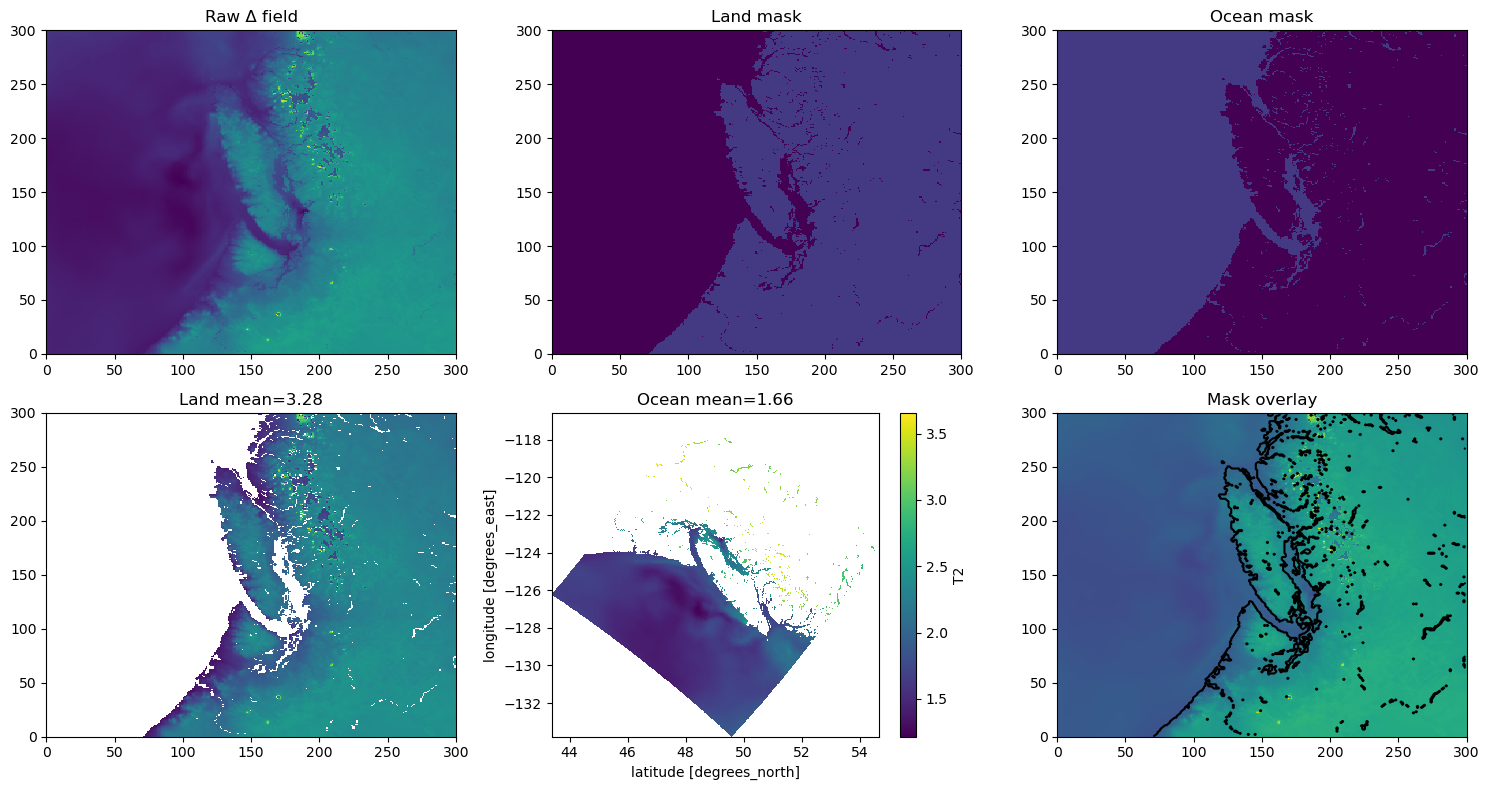

In [3]:
results_t = get_monthly_climatologies(
    variable='t',
    domain='d03'
)


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

sample lat <xarray.DataArray 'lat' (lon: 300, lat: 300)> Size: 720kB
[90000 values with dtype=float64]
Coordinates:
    lon      (lon, lat) float64 720kB ...
    lat      (lon, lat) float64 720kB ...
    time     datetime64[ns] 8B 1986-01-01
Attributes:
    standard_name:        latitude
    long_name:            latitude
    units:                degrees_north
    _CoordinateAxisType:  Lat
weight dims ('lon', 'lat')
jja.dims ('lon', 'lat')


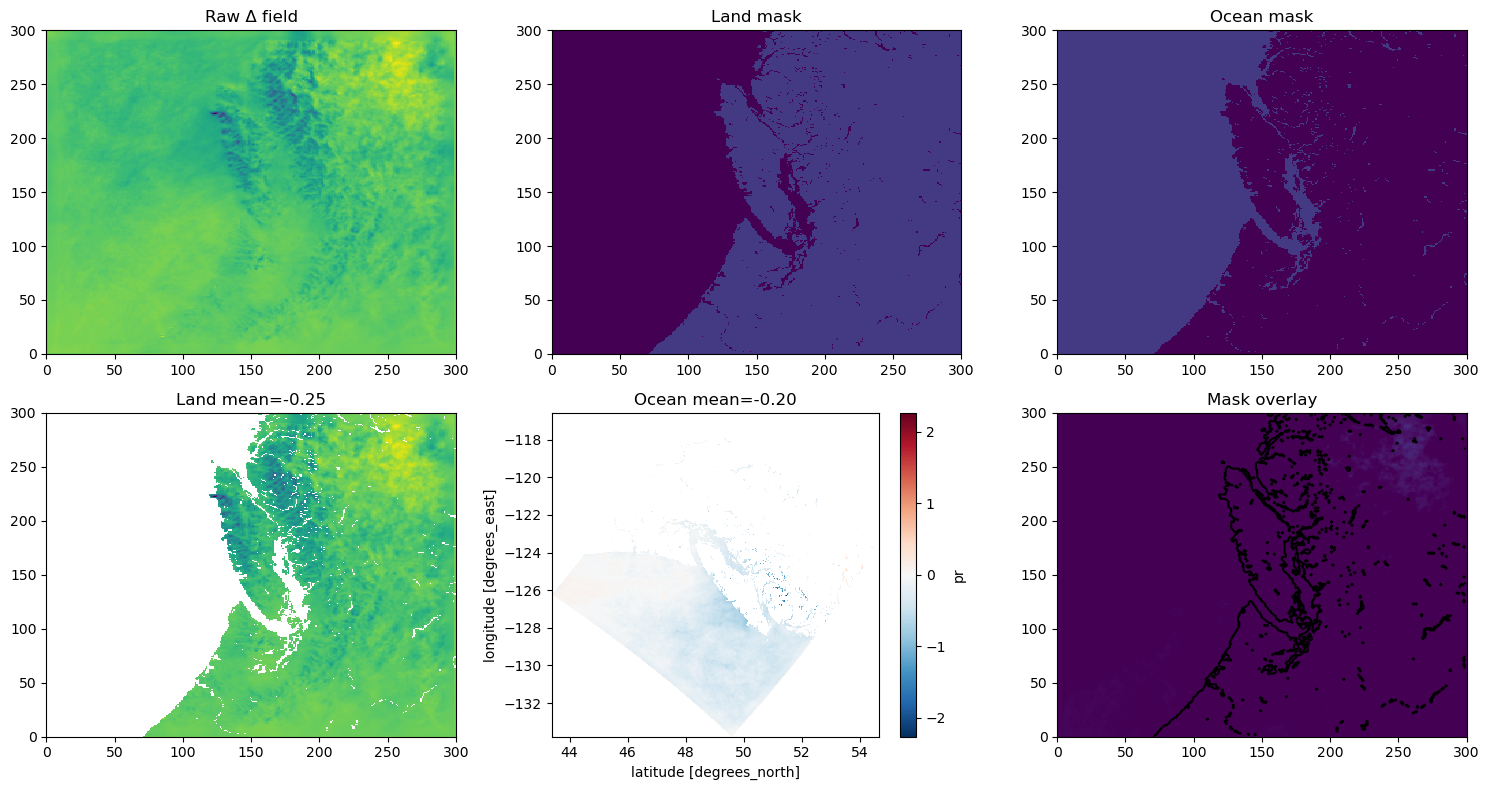

sample lat <xarray.DataArray 'lat' (lon: 300, lat: 300)> Size: 720kB
[90000 values with dtype=float64]
Coordinates:
    lon      (lon, lat) float64 720kB ...
    lat      (lon, lat) float64 720kB ...
    time     datetime64[ns] 8B 1986-01-01
Attributes:
    standard_name:        latitude
    long_name:            latitude
    units:                degrees_north
    _CoordinateAxisType:  Lat
weight dims ('lon', 'lat')
jja.dims ('lon', 'lat')


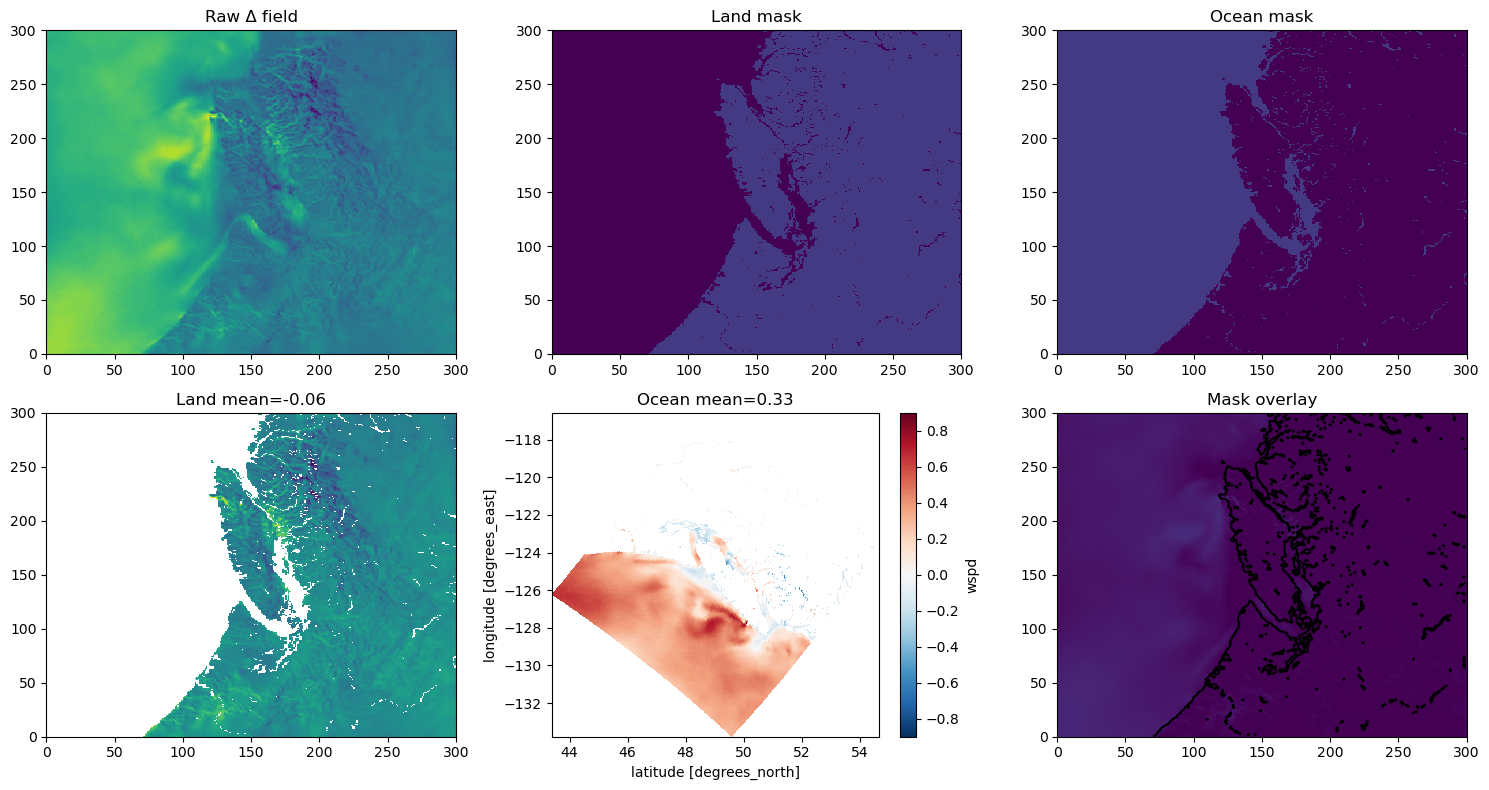

In [4]:

results_pr = get_monthly_climatologies(
    variable='pr',
    domain='d03'
)

results_wind = get_monthly_climatologies(
    variable='wind',
    domain='d03'
)

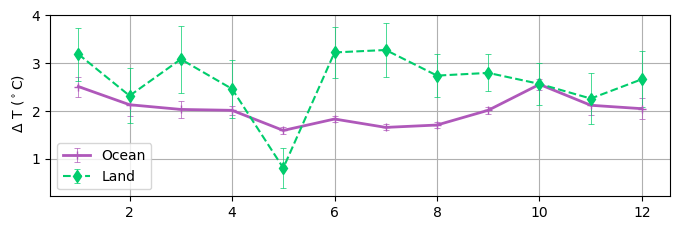

In [5]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)

plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months, results_t['delta45']['ocean'], yerr=results_t['delta45']['ocean_sem'],
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta45']['land'], yerr=results_t['delta45']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)
plt.legend()

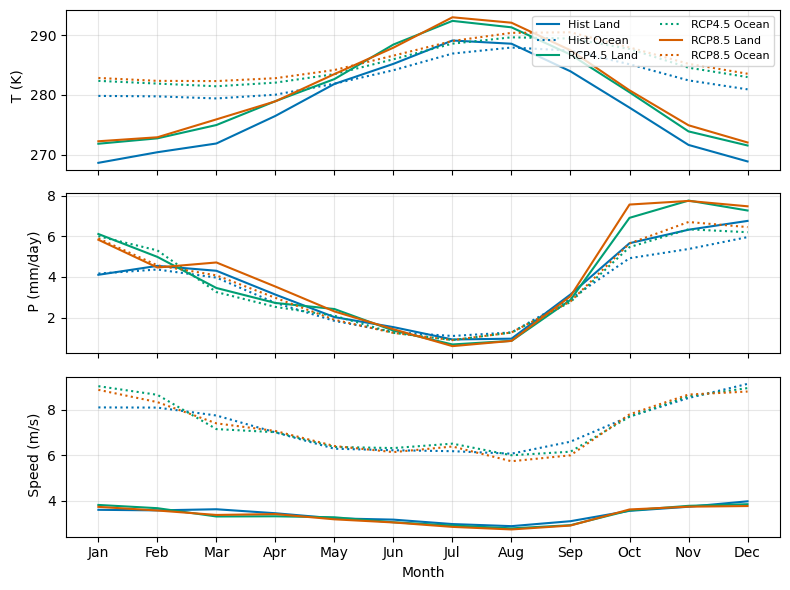

In [6]:
import numpy as np
import matplotlib.pyplot as plt

months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


# ============================================================
# Load results
# ============================================================

t = results_t
pr = results_pr
w = results_wind


# ============================================================
# Colorblind-safe palette (Okabe-Ito style)
# ============================================================

colors = {
    'hist':  '#0072B2',  # blue
    'rcp45': '#009E73',  # green
    'rcp85': '#D55E00'   # vermillion
}


# ============================================================
# Line styles for surface type
# ============================================================

linestyles = {
    'land': '-',
    'ocean': ':'
}


# ============================================================
# Helper function
# ============================================================

def plot_panel(ax, res, title):

    # Historical
    ax.plot(months, res['historical']['land'],
            color=colors['hist'], linestyle=linestyles['land'],
            label='Hist Land')

    ax.plot(months, res['historical']['ocean'],
            color=colors['hist'], linestyle=linestyles['ocean'],
            label='Hist Ocean')

    # RCP4.5
    ax.plot(months, res['rcp45']['land'],
            color=colors['rcp45'], linestyle=linestyles['land'],
            label='RCP4.5 Land')

    ax.plot(months, res['rcp45']['ocean'],
            color=colors['rcp45'], linestyle=linestyles['ocean'],
            label='RCP4.5 Ocean')

    # RCP8.5
    ax.plot(months, res['rcp85']['land'],
            color=colors['rcp85'], linestyle=linestyles['land'],
            label='RCP8.5 Land')

    ax.plot(months, res['rcp85']['ocean'],
            color=colors['rcp85'], linestyle=linestyles['ocean'],
            label='RCP8.5 Ocean')

    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    #ax.set_title(title)
    ax.grid(True, alpha=0.3)
        


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)


plot_panel(axes[0], t, 'Temperature')
axes[0].set_ylabel(r'  T (K)')

plot_panel(axes[1], pr, 'Precipitation')
axes[1].set_ylabel(r' P (mm/day)')

plot_panel(axes[2], w, 'Wind')
plt.ylabel(r' Speed (m/s)')
axes[2].set_xlabel('Month')


axes[0].legend(loc='upper right', ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig('seasonal_cycles.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


plt.show()

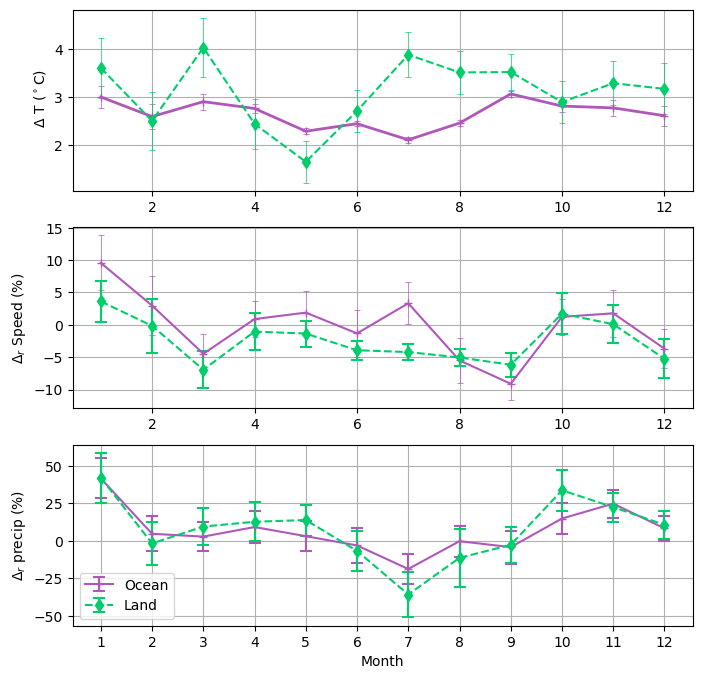

In [7]:
#now plot the seasonal cycle for each 
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months, results_t['delta85']['ocean'], yerr=results_t['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta85']['land'], yerr=results_t['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_wind['delta85']['ocean'], yerr=results_wind['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_wind['delta85']['land'], yerr=results_wind['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
#plt.plot(months, do_w_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_w_85, label='Land', linestyle='--', marker='d', color=color1, markeredgecolor=color1)

plt.grid(True)
plt.ylabel(r'$\Delta_r$ Speed (%)')

#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_pr['delta85']['ocean'], yerr=results_pr['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=4, capthick=1.5, elinewidth=1.5)

plt.errorbar(months, results_pr['delta85']['land'], yerr=results_pr['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
plt.ylabel(r'$\Delta_r$ precip (%)')

plt.xlabel('Month')
#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
plt.grid(True)
plt.legend()

In [8]:
import numpy as np
import matplotlib.pyplot as plt





# ============================================================
# Helper function
# ============================================================

def seasonal_amplitude(clim):
    """
    Compute summer minus winter climatological mean.

    Parameters
    ----------
    clim : ndarray(12,)

    Returns
    -------
    float
    """
# ============================================================
# Define seasons
# ============================================================

    summer_idx = [5, 6, 7]   # Jun, Jul, Aug
    
    winter_idx = [11, 0, 1]  # Dec, Jan, Feb
    summer_mean = np.mean(clim[summer_idx])
    winter_mean = np.mean(clim[winter_idx])

    return summer_mean - winter_mean


# ============================================================
# Compute amplitudes
# ============================================================
def getAmps(results):
    # Historical
    hist_land_amp = seasonal_amplitude(
        results['historical']['land']
    )
    
    hist_ocean_amp = seasonal_amplitude(
        results['historical']['ocean']
    )
    
    # RCP4.5
    rcp45_land_amp = seasonal_amplitude(
        results['rcp45']['land']
    )
    
    rcp45_ocean_amp = seasonal_amplitude(
        results['rcp45']['ocean']
    )
    
    # RCP8.5
    rcp85_land_amp = seasonal_amplitude(
        results['rcp85']['land']
    )
    
    rcp85_ocean_amp = seasonal_amplitude(
        results['rcp85']['ocean']
    )
    
    print(rcp85_ocean_amp, hist_ocean_amp)
    # ============================================================
    # Compute change relative to historical
    # ============================================================
    
    delta45_land_amp = 100.0* (rcp45_land_amp - hist_land_amp)/hist_land_amp
    delta45_ocean_amp = 100.0*(rcp45_ocean_amp - hist_ocean_amp)/hist_ocean_amp
    
    delta85_land_amp = 100.0*(rcp85_land_amp - hist_land_amp)/hist_land_amp
    delta85_ocean_amp = 100.0*(rcp85_ocean_amp - hist_ocean_amp)/hist_ocean_amp
    
    
    delta45_amp_abs = rcp45_land_amp - hist_land_amp
    delta85_amp_abs = rcp85_land_amp - hist_land_amp
    print('raw amps, 45, 85', delta45_amp_abs, delta85_amp_abs)

    return delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp

labels = ['land', 'ocean']
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_t)



5.742747153724906 6.14174537714257
raw amps, 45, 85 0.3563346793554274 0.2758946035293661


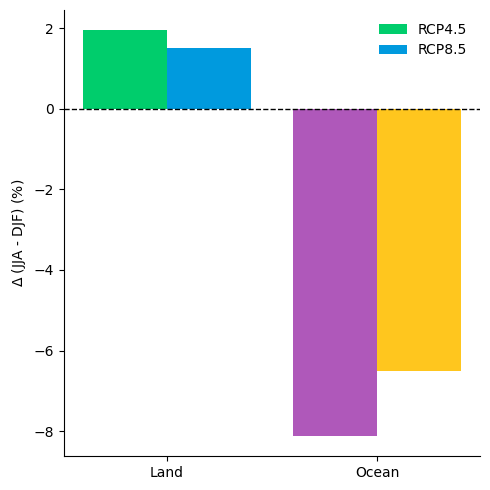

In [9]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Land', 'Ocean']
x = np.arange(len(labels))*.25
width = 0.1

fig, ax = plt.subplots(figsize=(5, 5))

# Pack data consistently as arrays
rcp45 = np.array([delta45_land_amp, delta45_ocean_amp])
rcp85 = np.array([delta85_land_amp, delta85_ocean_amp])

# Bars
ax.bar(x - width/2, rcp45, width,
       label='RCP4.5', color=[color1,color2])

ax.bar(x + width/2, rcp85, width,
       label='RCP8.5', color=[color4,color3])

# Zero reference
ax.axhline(0, linestyle='--', linewidth=1, color='black')

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('$\Delta$ (JJA - DJF) (%)')

ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

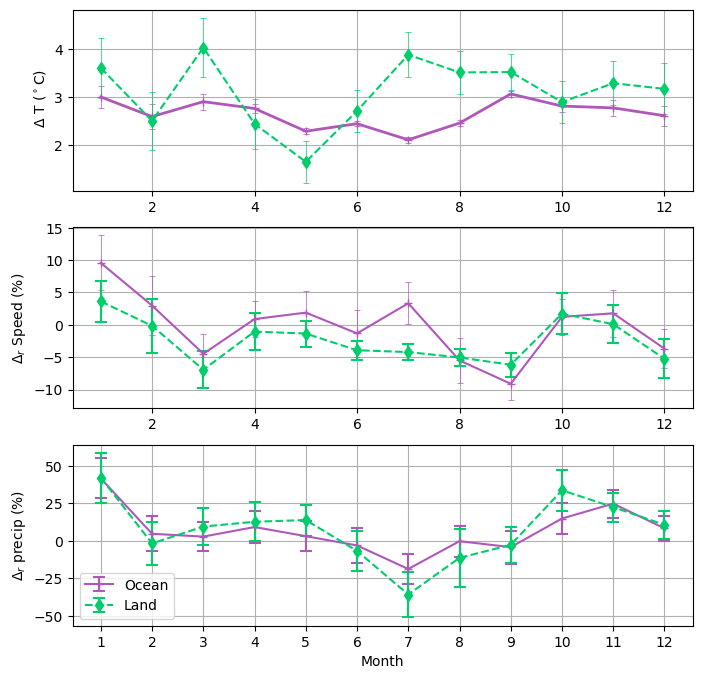

In [10]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months,results_t['delta85']['ocean'], yerr=results_t['delta85']['ocean_sem'] ,
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta85']['land'], yerr=results_t['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_wind['delta85']['ocean'], yerr=results_wind['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_wind['delta85']['land'], yerr=results_wind['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
#plt.plot(months, do_w_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_w_85, label='Land', linestyle='--', marker='d', color=color1, markeredgecolor=color1)

plt.grid(True)
plt.ylabel(r'$\Delta_r$ Speed (%)')

#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_pr['delta85']['ocean'], yerr=results_pr['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=4, capthick=1.5, elinewidth=1.5)

plt.errorbar(months, results_pr['delta85']['land'], yerr=results_pr['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
plt.ylabel(r'$\Delta_r$ precip (%)')

plt.xlabel('Month')
#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
plt.grid(True)
plt.legend()

In [11]:
print('annual average warming over land', np.mean(results_t['delta45']['land']), 'water', np.mean(results_t['delta45']['ocean']), ' difference ', np.mean(results_t['delta45']['ocean']-results_t['delta45']['land']))
print('annual average warming over land', np.mean(results_t['delta85']['land']), 'water', np.mean(results_t['delta85']['ocean']), ' difference ', np.mean(results_t['delta85']['ocean']-results_t['delta85']['land']))


annual average warming over land 2.617600519914698 water 2.0197420669647386  difference  -0.5978584529499594
annual average warming over land 3.097896568655026 water 2.6475621797795648  difference  -0.4503343888754614


5.742747153724906 6.14174537714257
raw amps, 45, 85 0.3563346793554274 0.2758946035293661
T [ 1.94793422 -8.12002558] [ 1.50820162 -6.49649569]
-4.514674145676972 -3.6218334681863995
raw amps, 45, 85 -1.1642446557011432 -0.9692811157807997
pr [29.06549252 30.11914242] [24.19820687 24.65162149]
-2.5911191757979264 -2.294465072484128
raw amps, 45, 85 -0.15339392177821898 -0.10348864295829108
wind [21.60039763 13.86006502] [14.57291014 12.92911829]


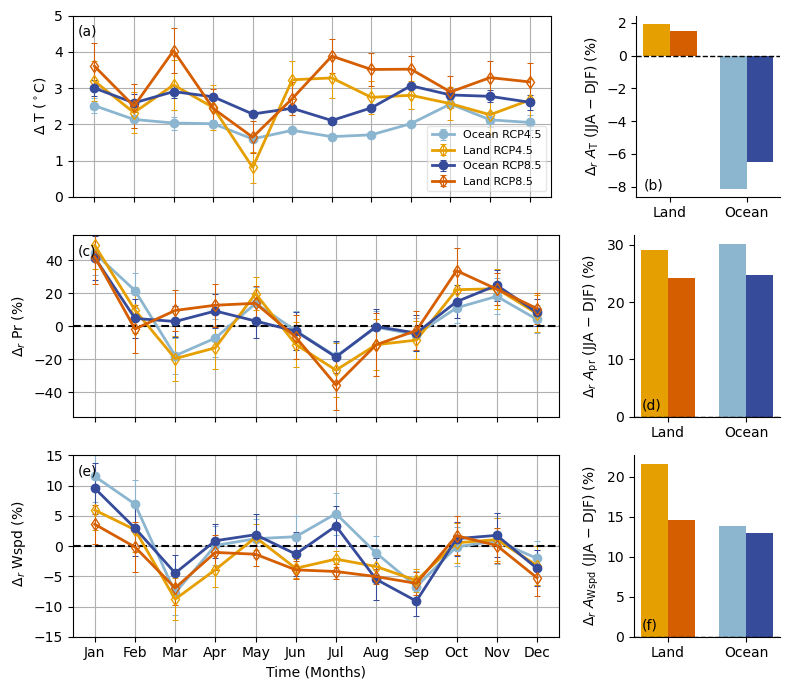

In [12]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95
# ============================================================
# Colors (keep your scheme)
# ============================================================

color3 = '#364B9A'  # ocean hist
color2 = '#8CB6D0'  # ocean RCP4.5

color4 = '#D55E00'  # land hist
color1 = '#E69F00'  # land RCP4.5


# ============================================================
# Helper: seasonal cycle error plot
# ============================================================

def plot_error(ax, res):

    caps = 2.5
    capw = 0.75
    capt = 0.75
    lw = 2

    # ------------------------
    # RCP4.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta45']['ocean'],
        yerr=res['delta45']['ocean_sem'],
        label='Ocean RCP4.5',
        marker='o',
        color=color2,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta45']['land'],
        yerr=res['delta45']['land_sem'],
        label='Land RCP4.5',
        marker='d',
        linestyle='-',
        color=color1,
        markerfacecolor='None',
        markeredgecolor=color1,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    # ------------------------
    # RCP8.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta85']['ocean'],
        yerr=res['delta85']['ocean_sem'],
        label='Ocean RCP8.5',
        marker='o',
        color=color3,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta85']['land'],
        yerr=res['delta85']['land_sem'],
        label='Land RCP8.5',
        marker='d',
        linestyle='-',
        color=color4,
        markerfacecolor='None',
        markeredgecolor=color4,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )


# ============================================================
# Figure
# ============================================================

plt.figure(figsize=(8, 7))
ax = plt.subplot(3, 1, 1)

plot_error(ax, results_t)

ax.set_ylabel(r'$\Delta $ T ($^\circ$C)')
ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
ax.legend(fontsize=8, framealpha=0.5)

ax.set_ylim([0, 5])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.85)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_t)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('T', rcp45_amp,rcp85_amp)

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP 4.5',
        color=[color1,color2])#'#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color=[color4,color3])#'#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{T}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(b)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

##################################
ax = plt.subplot(3, 1, 2)

plot_error(ax, results_pr)

ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
# zero line
ax.axhline(0, linestyle='--', linewidth=1.5, color='black')
#ax.legend(fontsize=8, framealpha=0.5)
plt.ylabel(r'$\Delta_r$ Pr (%)')

plt.ylim([-55,55])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_pr)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('pr', rcp45_amp,rcp85_amp)

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP 4.5',
        color=[color1,color2])#'#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color=[color4,color3])#'#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{pr}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(d)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
###############################
ax = plt.subplot(3, 1, 3)


plot_error(ax, results_wind)
ax.axhline(0, linestyle='--', linewidth=1.5, color='black')

ax.grid(True)
ax.set_xticks(months)

#ax.set_xticks(months)
ax.set_xticklabels(month_labels)
# zero line
#ax.set_xticklabels([])
#ax.legend(fontsize=8, framealpha=0.5)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Wspd (%)')
plt.xlabel('Time (Months)')


plt.ylim([-15,15])


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_wind)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('wind', rcp45_amp,rcp85_amp )
# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP 4.5',
        color=[color1,color2])#'#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color=[color4,color3])#'#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{Wspd}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(f)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[4], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


plt.tight_layout()
plt.show()

In [13]:
print(rcp45_amp,rcp85_amp)

[21.60039763 13.86006502] [14.57291014 12.92911829]
